In [ ]:
# importing all the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None) # Show all columns when displaying DataFrames

In [ ]:
# loading the dataset
df = pd.read_csv("C:\\Users\\zaids\\Downloads\\archive (2)\\retail_store_sales.csv")

In [ ]:
# sanity checks
df.head(20)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [4]:
df.shape

(12575, 11)

In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [7]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

In [204]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price Per Unit,11966.0,23.365912,10.743519,5.0,14.0,23.0,33.5,41.0
Quantity,11971.0,5.536380,2.857883,1.0,3.0,6.0,8.0,10.0
Total Spent,11971.0,129.652577,94.750697,5.0,51.0,108.5,192.0,410.0


In [ ]:
# identifying missing values
df.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [ ]:
# identifying the percentage of missing values in each column
df.isna().mean().multiply(100).sort_values(ascending=False)

Discount Applied    33.391650
Item                 9.646123
Price Per Unit       4.842942
Total Spent          4.803181
Quantity             4.803181
Transaction ID       0.000000
Customer ID          0.000000
Category             0.000000
Payment Method       0.000000
Location             0.000000
Transaction Date     0.000000
dtype: float64

### 'Item' , 'Price per unit', 'Quantity', 'Total Spent', and Discount applied have null values

In [22]:
# checking for duplicates

df.duplicated().sum()

np.int64(0)

In [23]:
df[df.duplicated()]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [25]:
# check on primary key
df[df.duplicated(subset=['Transaction ID'])]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [ ]:
df.describe(include='object').T  # to check the categorical columns and their unique values

,count,unique,top,freq
Transaction ID,12575,12575,TXN_6867343,1
Customer ID,12575,25,CUST_05,544
Category,12575,8,Electric household essentials,1591
Item,11362,200,Item_2_BEV,126
Payment Method,12575,3,Cash,4310
Location,12575,2,Online,6354
Transaction Date,12575,1114,2022-05-30,26
Discount Applied,8376,2,True,4219


In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price Per Unit,11966.0,23.365912,10.743519,5.0,14.0,23.0,33.5,41.0
Quantity,11971.0,5.536380,2.857883,1.0,3.0,6.0,8.0,10.0
Total Spent,11971.0,129.652577,94.750697,5.0,51.0,108.5,192.0,410.0


In [28]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [ ]:
# first i Will change the data type of date column to datetime

df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce') # what is errors = 'coerce' ? it will convert the invalid date to NaT (Not a Time) instead of raising an error

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              11362 non-null  object        
 4   Price Per Unit    11966 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  8376 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 1.1+ MB


In [ ]:
# identifying the unique values in categorical columns or garbaging values in categorical columns

for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() < 10:  # only print value counts for columns with less than 10 unique values
        print(f"Column'{col}': {df[col].value_counts()}")
        print("---"* 50)

Column'Category': Category
Electric household essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------
Column'Payment Method': Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------------------------------------
Column'Location': Location
Online      6354
In-store    6221
Name: count, dtype: int64
--------------------------------------------------------------------------------

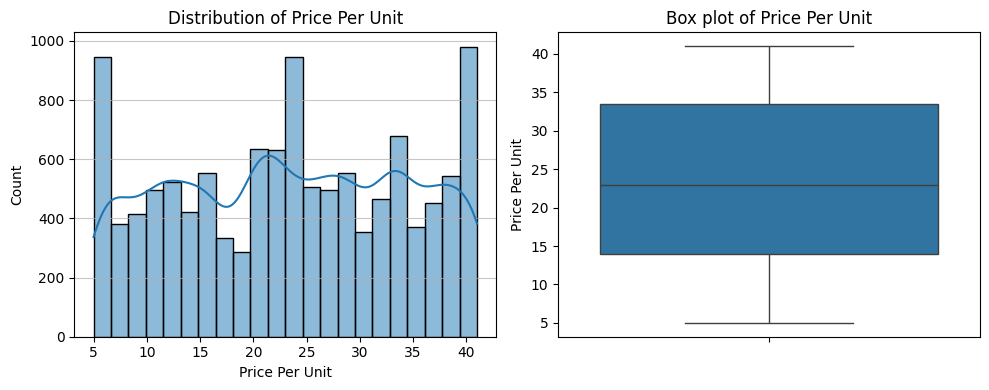

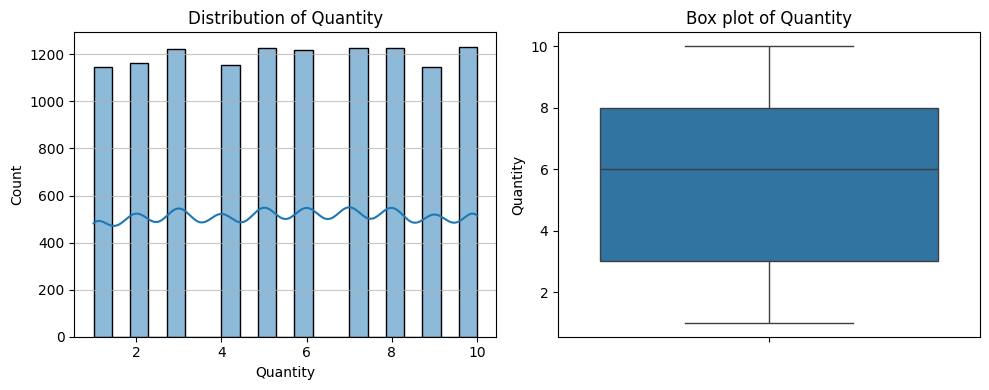

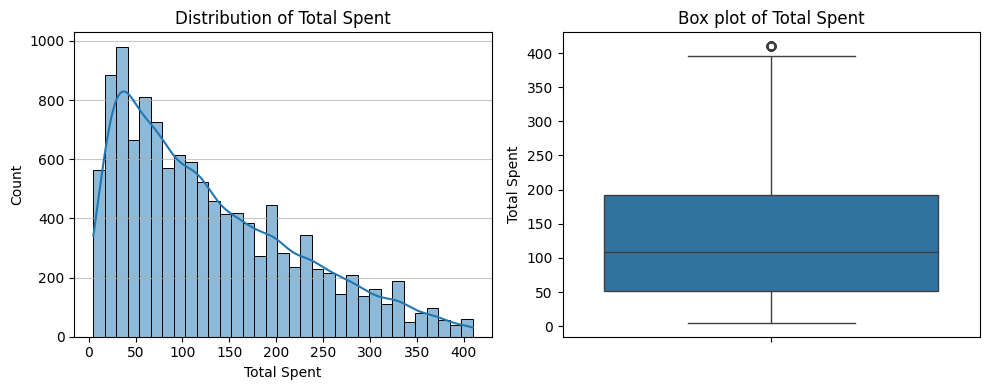

In [ ]:
# plot the distribution and box plot for the numerical columns to check for outliers so that we can choose how we need to treat the outliers in the data cleaning step 
# if the dssitribution is normally distributed then we can use mean and std Or Z test to treat the outliers but if the distribution is skewed then we can use median and IQR to treat the outliers

numerical_cols = df.select_dtypes(include=['number']).columns

for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)# what it means ? it means that we will plot 1 row and 2 columns and this is the first plot
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.grid(axis='y',alpha=0.7)
    
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
    
    plt.tight_layout()
    plt.show()

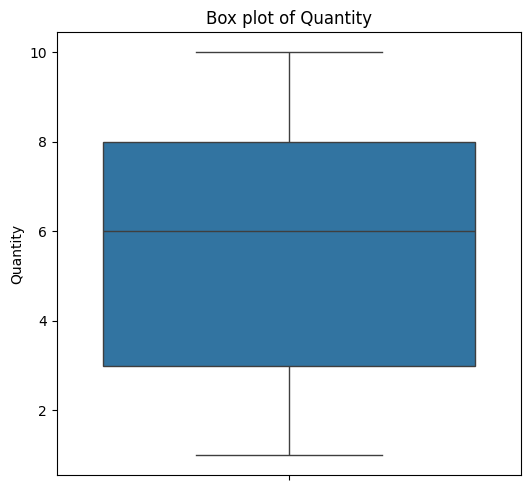

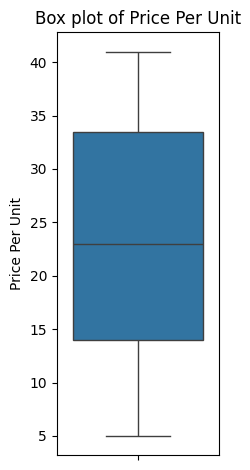

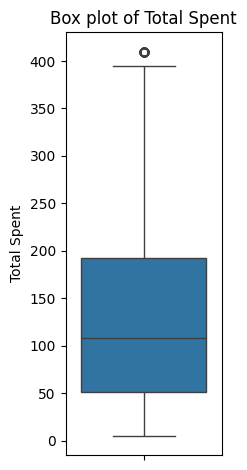

In [ ]:
# when checking for only selected numerical columsn

cols = ['Quantity', 'Price Per Unit', 'Total Spent']
plt.figure(figsize=(15,5))
for i , col in enumerate(cols,1): # what is the purpose of enumerate ? it will give us the index of the column and the column name itself
    plt.subplot(1,3, i) # what it means ? it means that we will plot 1 row and 3 columns and this is the i-th plot
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')

    
    plt.tight_layout()
    plt.show()

In [ ]:
# identifying the outlier rows in the 'Total Spent' column using the IQR method since the distribution of 'Total Spent' is right skewed and it has a long tail on the right side which indicates that it has outliers and we can use IQR method to treat the outliers in this column

Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Total Spent'] < lower_bound) | (df['Total Spent'] > upper_bound)]
print(f"Number of outliers in 'Total Spent': {outliers.shape[0]}")
print(len(outliers))
print(outliers[['Transaction ID', 'Total Spent']])

Number of outliers in 'Total Spent': 60
60
      Transaction ID  Total Spent
27       TXN_1599706        410.0
133      TXN_2953434        410.0
339      TXN_4374445        410.0
869      TXN_1814138        410.0
1060     TXN_3710081        410.0
1088     TXN_1273334        410.0
1468     TXN_1938135        410.0
1505     TXN_8520397        410.0
1568     TXN_8048041        410.0
1950     TXN_1860120        410.0
1983     TXN_6924479        410.0
2153     TXN_5338814        410.0
2180     TXN_1172555        410.0
2182     TXN_4047143        410.0
2540     TXN_2208547        410.0
2658     TXN_1227978        410.0
3036     TXN_2624160        410.0
3094     TXN_7177583        410.0
3778     TXN_7898457        410.0
4526     TXN_3142066        410.0
4780     TXN_3465682        410.0
5364     TXN_8384530        410.0
5745     TXN_3855536        410.0
5756     TXN_4286472        410.0
5819     TXN_4456347        410.0
5969     TXN_2058333        410.0
6174     TXN_4428473        410.0
6374 

In [191]:
# remove outliers from the 'Total Spent' column
df_cleaned = df[(df['Total Spent'] >= lower_bound) & (df['Total Spent'] <= upper_bound)]
print(f"Shape of original DataFrame: {df.shape}")
print(f"Shape of cleaned DataFrame: {df_cleaned.shape}")

Shape of original DataFrame: (12575, 11)
Shape of cleaned DataFrame: (11911, 11)


In [ ]:
df["Total Spent"].skew() 
# to check the skewness of the 'Total Spent' column > 0 means that the distribution is right skewed (positively skewed) 
# and < 0 means that the distribution is left skewed (negatively skewed) and = 0 means that the distribution is perfectly symmetrical

np.float64(0.8312947841720618)

### However we would not remove the outlier in this case 
“I typically use the IQR method for skewed data and Z-score for normally distributed data, and validate outliers based on business context before removing or capping them.”
Also outlier treatment is done only for continous numerical data we can do it for Total Spent, we dont do it for categorical and discrete variable and also target variable

In [77]:
df['Total Spent'] = np.where(df['Total Spent'] < 0, 0, df['Total Spent']) # replace negative values with 0 in the 'Total Spent' column

In [125]:
# methood 1 we can use np.where to replace the outliers in the 'Total Spent' column with the lower bound and upper bound values
df['Total_spend_capped_1'] = np.where(df['Total Spent'] < lower_bound, lower_bound,
                                    np.where(df['Total Spent'] > upper_bound, upper_bound, df['Total Spent']))

In [126]:
# validate the number of outliers after capping using method 2
((df['Total_spend_capped_1'] < lower_bound) | (df['Total_spend_capped_1'] > upper_bound)).sum()

np.int64(0)

In [127]:
outliers_after_capping = df[(df['Total_spend_capped_1'] < lower_bound) | (df['Total_spend_capped_1'] > upper_bound)]
print(f"Number of outliers after capping: {outliers_after_capping.shape[0]}")

Number of outliers after capping: 0


In [128]:
# method 2 clean logic
df["Total_Spent_capped_2"] = df["Total Spent"].clip(lower_bound, upper_bound) 
# what does clip do ? it will replace the values that are less than the lower bound with the lower bound value and 
# the values that are greater than the upper bound with the upper bound value

In [129]:
((df['Total_Spent_capped_2'] < lower_bound) | (df['Total_Spent_capped_2'] > upper_bound)).sum()

np.int64(0)

# Method 3 using function to cap all the numerical columns in the dataframe having an outlier problem
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[column] = np.where(df[column] < lower_bound, lower_bound,
                          np.where(df[column] > upper_bound, upper_bound, df[column]))
    
    return df
''' df[f"{column}_capped"] = df[column].clip(lower_bound, upper_bound)  - when you dont want to modify the original column and create a new column with the capped values you can use this line instead of the np.where line above
'''

# test the function on the 'Total Spent' column
df = cap_outliers(df, 'Total Spent')


# simpler function

def whisker(col):
    q1,q3 = np.percentile(col,[25,75])
    iqr = q3 - q1
    lw = q1 - 1.5* iqr
    uw = q3 + 1.5 * iqr
    return lw , uw

In [ ]:
def whisker(col):
    q1,q3 = np.nanpercentile(col,[25,75]) # what is np.nanpercentile ? it will calculate the percentiles while ignoring the NaN values in the column
    iqr = q3 - q1
    lw = q1 - 1.5*iqr
    uw = q3 + 1.5 *iqr
    return lw,uw

In [138]:
whisker(df["Total Spent"])

(np.float64(-160.5), np.float64(403.5))

# to make it dynamic and able to process multiple columns without hardcoding the column names, we can use a loop to iterate through the desired columns and apply the capping logic to each column.
for col in ['Total Spent', 'Price Per Unit', 'Quantity']:
    lw, uw = whisker(df[col])
    df[col] = df[col].clip(lw, uw) # this will apply the capping logic to each column in the list and replace the original column with the capped values

In [139]:
df["Total_spend_capped_1"].min(), df["Total_spend_capped_1"].max()

(np.float64(5.0), np.float64(403.5))

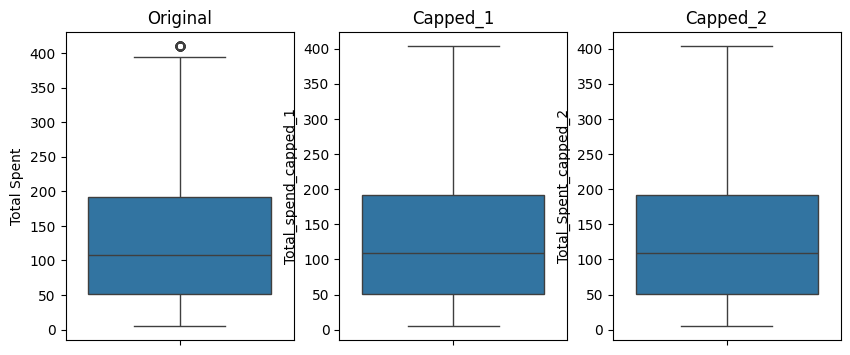

In [ ]:
# box plot to compare the original and capped columns
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
sns.boxplot(y = df["Total Spent"])
plt.title("Original")

plt.subplot(1,3,2)
sns.boxplot(y = df["Total_spend_capped_1"])
plt.title("Capped_1")


plt.subplot(1,3,3)
sns.boxplot(y = df["Total_Spent_capped_2"])
plt.title("Capped_2")
plt.show()

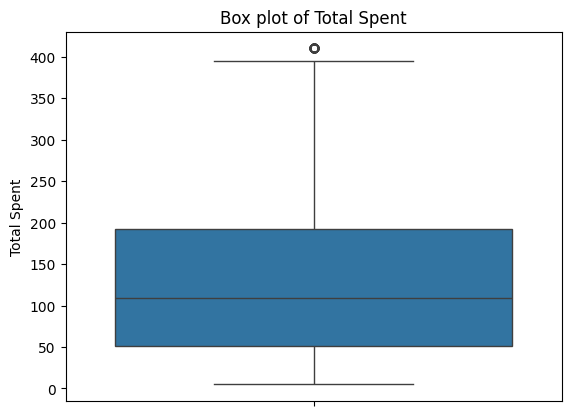

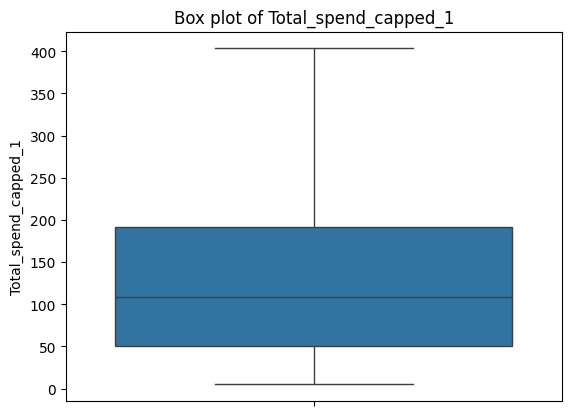

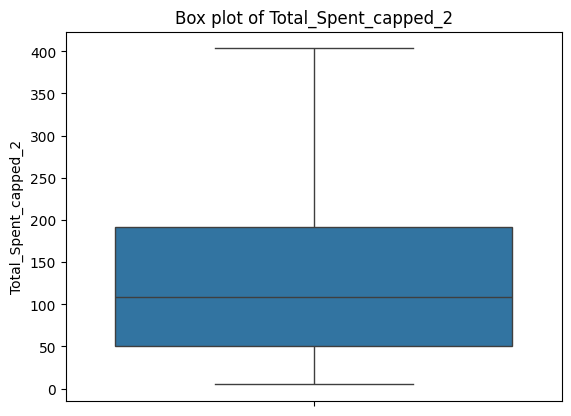

In [151]:
for col in ['Total Spent', 'Total_spend_capped_1', 'Total_Spent_capped_2']:
    sns.boxplot(y = df[col])
    plt.title(f'Box plot of {col}')
    plt.show()

# now you can see that the outliers are removed 


When the data is Normally distributed we can use the mean and standard deviation to cap the outliers instead of using the IQR method
Or we can use the z-score method to remove the outliers by calculating the z-score for each value and removing the values that have a z-score greater than a certain threshold (e.g., 3 or -3)

In [ ]:
from scipy.stats import zscore

df["z_score"] = zscore(df["Total Spent"])

outliers = df[df["z_score"].abs() > 3] # what does abs() do ? it will return the absolute value of the z_score, so we can check for both positive and negative outliers

outliers[["Transaction ID", "Total Spent", "z_score"]]

df = df[~df["z_score"].abs() > 3] # what does ~ do ? it will return the inverse of the condition, so we will keep the rows that are not outliers based on the z_score method

# however zscore method will not work becasue the distribution of the 'Total Spent' column is right skewed and not normal, so we cannot use the z-score method to identify outliers in this case.

,Transaction ID,Total Spent,z_score


In [154]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Price Per Unit,11966.0,23.365912,5.0,14.0,23.0,33.5,41.0,10.743519
Quantity,11971.0,5.53638,1.0,3.0,6.0,8.0,10.0,2.857883
Total Spent,11971.0,129.652577,5.0,51.0,108.5,192.0,410.0,94.750697
Transaction Date,12575,2023-07-12 20:23:41.105368064,2022-01-01 00:00:00,2022-09-30 00:00:00,2023-07-13 00:00:00,2024-04-24 00:00:00,2025-01-18 00:00:00,NaN
Total_spend_capped_1,11971.0,129.619998,5.0,51.0,108.5,192.0,403.5,94.655359
Total_Spent_capped_2,11971.0,129.619998,5.0,51.0,108.5,192.0,403.5,94.655359
z_score,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [192]:
# now we know that we will be using IQR method to handle the outliers in the 'Total Spent' column and we will be using the capped columns for our analysis instead of the original 'Total Spent' column.
df['Total Spent'] = df['Total Spent'].clip(lower_bound, upper_bound)


In [193]:
df['Total Spent'].min(), df['Total Spent'].max()

(np.float64(5.0), np.float64(403.5))

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [194]:
df.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [171]:
# now we will work on eliminating null values first for numerical columns

# as the data is right skewed  we will use the median

""" for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(df[col].median(),inplace=True)  """

for col in ["Quantity", "Price Per Unit", "Total Spent"]:
      df[col].fillna(df[col].median())

In [195]:
for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(df[col].median())

In [196]:
df.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              11362 non-null  object        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  8376 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 1.1+ MB


In [ ]:
# now we will remove null values for categorical columns either by replacing them with the mode or with a specific value that makes sense for the column
# specifially Item and Discount Applied column ( in discount Applied Replace Nan With False)
# for col in df.select_dtypes(include=['object']).columns:

df['Item'] = df['Item'].fillna("Unknown") # replace NaN values with "Unknown" in the 'Item' column
df['Discount Applied'] = df['Discount Applied'].fillna(False) # replace NaN values with False in the 'Discount Applied' column

# do not use inplace = True in the fillna method because it will return None and we will lose the original column values, so we need to assign the result back to the original column or use inplace = False (default value)

In [200]:
# now check again for null values after handling them
df.isna().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

In [ ]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
